# Fitting plotting notebook

This notebook shows how to use the Plotly fitting tools in Jupyter.

It covers:
- plotting raw fitting data
- overlaying an initial isotherm curve
- overlaying a fitted isotherm curve
- using callable models on an automatically generated pressure grid

Expected input:
- one or more raw fitting data files
- optionally `simulation.json`


In [1]:
from ruptura.plot_fitting import FittingPlotly
import numpy as np


## Build the plotter

In [ ]:
plotter = FittingPlotly.from_simulation_json("simulation.json", "CoBDP_fitted.json")
plotter

## Raw data only

Use this first to verify that the input columns are correct.

In [6]:
plotter.all_fit_figure()

Text(0, 0.5, 'Loading, q / mol kg${-1}$ Pa$^{-1}$')

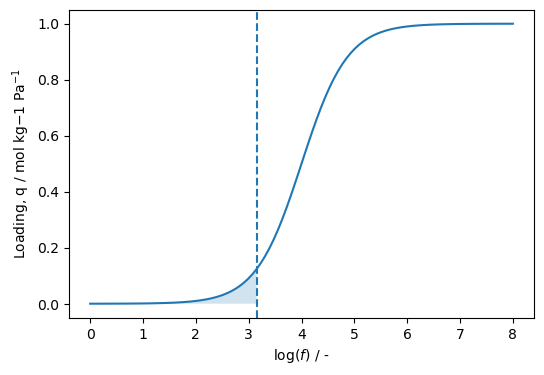

In [49]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
f = np.logspace(0, 8, 100)
q = 1
b = 1e-4
vl = 40
ig = np.cumsum(q * b / (1 + b * f))

# ax.plot(f, b * f / (1 + b * f))
ax.plot(np.log10(f), q * b * f / (1 + b * f))
ax.fill_between(np.log10(f)[:vl], 0, (q * b * f / (1 + b * f))[:vl], alpha=0.2)
ax.axvline(np.log10(f)[vl - 1], ls='--')
# ax.set_xscale('log')
# ax.set_ylim(0, 1.05 * max(q * b / (1 + b * f)))
ax.set_xlabel(r"log($f$) / -")
ax.set_ylabel(r"Loading, q / mol kg${-1}$ Pa$^{-1}$")

Text(0.5, 0, 'Fugacity, $f$ / Pa')

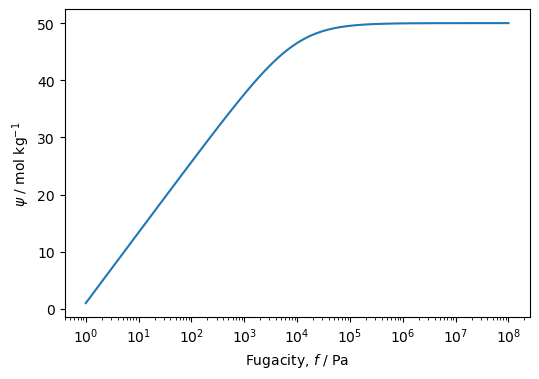

In [39]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(f, ig)
ax.set_xscale('log')
ax.set_ylabel(r"$\psi$ / mol kg$^{-1}$")
ax.set_xlabel(r"Fugacity, $f$ / Pa")